# Tratamento dos dados


In [1]:
%%html
<link rel="stylesheet" href="./style.css">

In [2]:
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

from data import a_df, normalize_features, numerical_columns


'Data types:'

age                    int64
systolic_bp            int64
diastolic_bp           int64
blood_sugar          float64
body_temperature     float64
heart_rate             int64
risk_level          category
dtype: object

'\nMissing values:'

age                 0
systolic_bp         0
diastolic_bp        0
blood_sugar         0
body_temperature    0
heart_rate          0
risk_level          0
dtype: int64

'\nDuplicated rows:'

np.int64(9)

In [3]:
tg_df = a_df.copy()
tg_numerical_columns = numerical_columns.copy()

nm_df = normalize_features(
    data_frame=a_df,
    numerical_columns=numerical_columns,
)

In [4]:
def generate_correlation_matrix(matrix: pd.DataFrame, title: str):
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        matrix,
        annot=True,  # mostra os valores
        fmt=".2f",  # duas casas decimais
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Características numéricas


In [5]:
def analyse_numerical_correlation(numerical_columns: pd.DataFrame):

    spearman_correlation = numerical_columns.corr(method="spearman")
    generate_correlation_matrix(
        spearman_correlation, "Matriz de correlação de Spearman"
    )

    pearson_correlation = numerical_columns.corr(method="pearson")
    generate_correlation_matrix(pearson_correlation, "Matriz de correlação de Pearson")

    pearson_correlation_abs = pearson_correlation.abs()
    upper_triangle = pd.DataFrame(
        np.triu(
            np.ones(pearson_correlation_abs.shape, dtype=bool),
            k=1,
        ),
        index=pearson_correlation_abs.index,
        columns=pearson_correlation_abs.columns,
    )

    pairs = cast(
        pd.Series,
        pearson_correlation_abs.where(upper_triangle).stack(),
    )
    pairs = pairs.sort_values(ascending=False)

    strong_pairs = pairs[pairs >= 0.7]
    strong_pairs_df = strong_pairs.rename_axis(
        ["Variável 1", "Variável 2"]
    ).reset_index()

    strong_pairs_df.columns = [
        "Variável 1",
        "Variável 2",
        "Correlação",
    ]

    strong_pairs_df["Correlação"] = strong_pairs_df["Correlação"].map(
        lambda value: f"{value:.3f}"
    )

    display(
        HTML(
            """
            <table>
                <caption>Pares fortemente correlacionados (|r| >= 0.8)</caption>
                <thead>
                    <tr>
                        <th>Variável 1</th>
                        <th>Variável 2</th>
                        <th>Correlação</th>
                    </tr>
                </thead>
                <tbody>
            """
            + "".join(
                f"<tr><td>{row[0]}</td><td>{row[1]}</td><td>{row[2]}</td></tr>"
                for row in strong_pairs_df.itertuples(index=False, name=None)
            )
            + """
                </tbody>
            </table>
            """
        )
    )

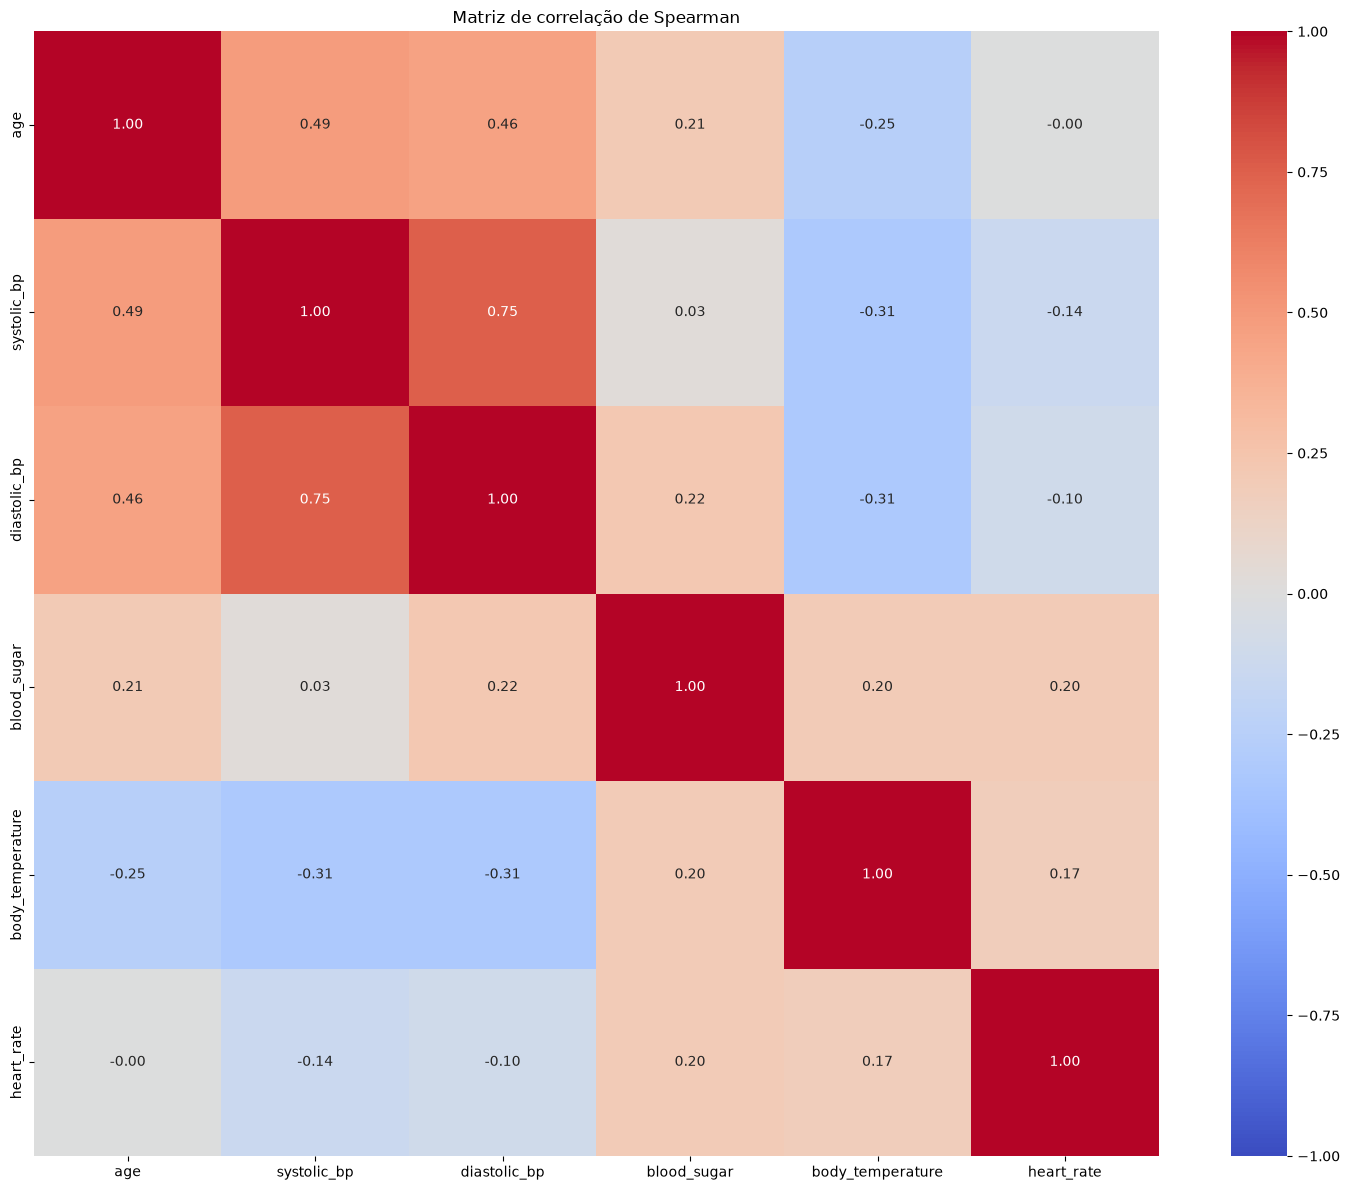

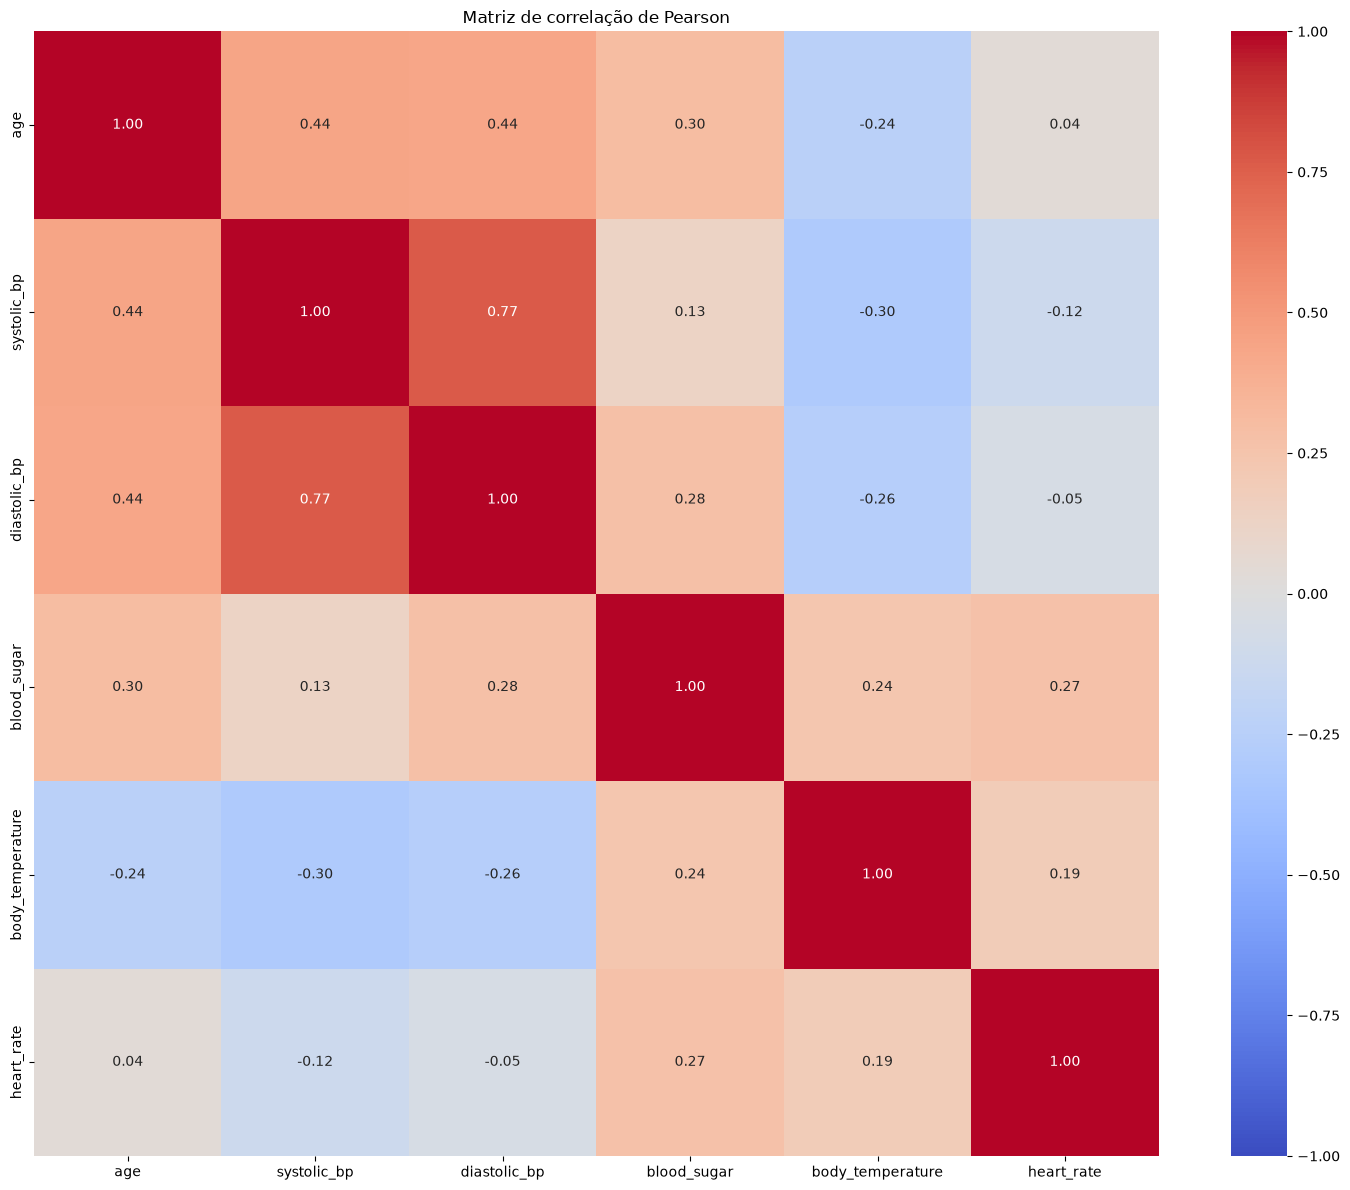

Variável 1,Variável 2,Correlação
systolic_bp,diastolic_bp,0.770


In [6]:
analyse_numerical_correlation(numerical_columns=nm_df[numerical_columns])

### Remoção de características

Foi removida a característica `diastolic_bp`, por apresentar alta correlação com a característica `systolic_bp`.


In [7]:
def drop_numerical_feature(name: str):
    if name in tg_numerical_columns:
        tg_numerical_columns.remove(name)
    return tg_df.drop(columns=[name])


tg_df = drop_numerical_feature("diastolic_bp")


In [8]:
t_numerical_columns = tg_numerical_columns.copy()
t_df = tg_df.copy()